In [1]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Audio, display
from collections import Counter
from pynwb import NWBHDF5IO
import scipy.signal

import h5py
import gc
import json

#import ipywidgets as widgets

from extract_features import extractHG, stackFeatures, downsampleLabels

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from extract_features import extractHG, stackFeatures, downsampleLabels

from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from phonetic_dictionary import PhoneticDictionary
from feature_vizualizer import PhonemeFeatureVisualizer
from extract_features import extractHG, downsampleLabels, extractMelSpecs
from pipeline import UnifiedPhonemePipeline
from config import BIDS_PATH, OUTPUT_PATH, RESULTS_PATH, DUTCH_30_PATH, DUTCH_10_PATH, get_dataset_paths

C:\Users\irina\anaconda3\Lib\site-packages\mne\externals\tempita\__init__.py:35: DeprecationWarning: 'cgi' is deprecated and slated for removal in Python 3.13
  import cgi


Running from clean repo, using data from: D:\Documents\UM DACS\bachelor\UM DACS\bachelor\mozg\code\SingleWordProductionDutch


In [2]:
# Check we're using the right paths
print(f"BIDS path: {BIDS_PATH}")
print(f"Output path: {OUTPUT_PATH}")
print(f"Results path: {RESULTS_PATH}")
# Define paths
path_bids = BIDS_PATH # './SingleWordProductionDutch-iBIDS'  # Path to the BIDS dataset
path_output = OUTPUT_PATH #'./features'  # Path to save extracted features
path_results = RESULTS_PATH #'./results'  # Path to save results
paths_30 = get_dataset_paths('dutch30')

BIDS path: D:\Documents\UM DACS\bachelor\UM DACS\bachelor\mozg\code\SingleWordProductionDutch\Dutch_10patients
Output path: D:\Documents\UM DACS\bachelor\UM DACS\bachelor\mozg\code\SingleWordProductionDutch\features
Results path: D:\Documents\UM DACS\bachelor\UM DACS\bachelor\mozg\code\SingleWordProductionDutch\results


In [3]:
visualizer = PhonemeFeatureVisualizer(output_dir='./phoneme_visualizations')

In [4]:
# Pipeline creation with PCA components management
use_augmentation = True
feature_extraction_method = 'high_gamma' #'high_gamma'  #
pca_components = 100  # Use your optimal value determined earlier

In [5]:
# fix_and_pretrain_10patients.py
# Try to load existing pipeline, otherwise create new one
try:
    # Try loading existing pipeline
    pipeline = UnifiedPhonemePipeline.load_saved(path_results, method=feature_extraction_method)
    print(f"Loaded existing {feature_extraction_method} pipeline")
    
    # Check and update PCA components if needed
    current_pca = getattr(pipeline, 'pca_components', None)
    if current_pca != pca_components:
        print(f"Updating PCA components from {current_pca} to {pca_components}")
        pipeline.set_pca_components(optimal_pca_components)
        
        # Re-run data steps with new PCA components
        print("Re-processing data with updated PCA components...")
        pipeline.step4_initialize_detector()            
        pipeline.step5_accumulate_data(
            train_batches=8,  # Start with fewer batches
            test_batches=0,   # Smaller test set
            batch_size=32     # Smaller batch size
        )  
        pipeline.step6_resolve_unknowns()
        pipeline.step7_filter_unknowns()
        
        # Save the updated pipeline
        pipeline.save()
        print(f"Updated and saved {feature_extraction_method} pipeline with {optimal_pca_components} PCA components")
    
except (FileNotFoundError, AttributeError, TypeError) as e:
    # No existing pipeline found, create new one
    print(f"No existing {feature_extraction_method} pipeline found. Creating new one...")
    
    pipeline = UnifiedPhonemePipeline(
        path_bids=path_bids,
        path_output=path_output,
        path_results=path_results,
        feature_extraction_method='high_gamma',
        unknown_keep_ratio=0.1,
        channel_correlation_threshold=0.3,
        prioritize_regions=False,
        channel_selection='best_correlation',
        pca_components=pca_components,
        use_rest_periods=False,
        rest_normalization=False,
        rest_as_class=False,
        debug_mode=True  # Set to False to reduce output
    )
    
    # Run all steps
    print("Running pipeline steps...")
    pipeline.step1_initialize_decoder()
    pipeline.step2_stratify_participants()    
    pipeline.step3_create_split()
    pipeline.step4_initialize_detector() 
    pipeline.step5_accumulate_data(
            train_batches=8,  # Start with fewer batches
            test_batches=0,   # Smaller test set
            batch_size=32     # Smaller batch size
        )   

#     pipeline.step6_resolve_unknowns()
#     pipeline.step7_filter_unknowns()

    # Now continue - but check we have data first
    if pipeline.train and len(pipeline.train['features']) > 0:
        pipeline.step6_resolve_unknowns()
        pipeline.step7_filter_unknowns()
        pipeline.save()
    else:
        print("No data accumulated - cannot continue")

# The pipeline is now ready to use with optimal PCA components
print(f"Pipeline ready with {feature_extraction_method} features and {pca_components} PCA components")

Loading newest matching pipeline: pipeline_high_gamma_pca100_20250913_210012.pkl
PhoneticDictionary: Initialized with DEBUG_MODE=False
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, PCA=50, groups=True
UnifiedPhonemePipeline: Loaded high_gamma pipeline with PCA components=100
UnifiedPhonemePipeline: Train: 256 samples, Test: 0 samples
Loaded existing high_gamma pipeline
Pipeline ready with high_gamma features and 100 PCA components


In [6]:
# Load the saved pipeline
saved_files = [f for f in os.listdir(RESULTS_PATH) if f.startswith('pipeline_') and f.endswith('.pkl')]
print(f"Found saved files: {saved_files}")

if saved_files:
    latest_file = sorted(saved_files)[-1]
    filepath = os.path.join(RESULTS_PATH, latest_file)
    
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    
    # Check structure
    print(f"\nLoaded {latest_file}")
    print(f"Keys in saved data: {data.keys()}")
    
    if 'train' in data and data['train']:
        train = data['train']
        print(f"\nTraining data features: {len(train.get('features', []))} samples")
        if train.get('features'):
            print(f"  Feature shape: {train['features'][0].shape}")
        print(f"  Labels: {len(train.get('phoneme_labels', []))} labels")
        
        # Check label distribution
        if 'phoneme_labels' in train:
            label_counts = Counter(train['phoneme_labels'])
            print(f"  Unique labels: {len(label_counts)}")
            print(f"  Top 5 labels: {label_counts.most_common(5)}")
    
    if 'test' in data and data['test']:
        test = data['test']
        print(f"\nTest data fatures: {len(test.get('features', []))}")
        print(f"  Labels: {len(test.get('phoneme_labels', []))}")

Found saved files: ['pipeline_high_gamma_pca100_20250913_210012.pkl']

Loaded pipeline_high_gamma_pca100_20250913_210012.pkl
Keys in saved data: dict_keys(['metadata', 'train', 'test', 'train_filtered'])

Training data features: 256 samples
  Feature shape: (294, 100)
  Labels: 256 labels
  Unique labels: 41
  Top 5 labels: [('t', 30), ('r', 18), ('ə', 17), ('d', 16), ('s', 15)]

Test data fatures: 0
  Labels: 0


In [8]:
# # Prepare data for sklearn
# if train.get('features') and len(train['features']) > 0:
#     # Flatten features to 2D array
#     X_train = []
#     for feat in train['features']:
#         if len(feat.shape) == 1:
#             X_train.append(feat)
#         else:
#             # If 2D, flatten or take mean
#             X_train.append(feat.flatten())
    
#     # Make all features same length (truncate or pad)
#     max_len = max(len(f) for f in X_train)
#     X_train_fixed = []
#     for feat in X_train:
#         if len(feat) < max_len:
#             # Pad with zeros
#             padded = np.zeros(max_len)
#             padded[:len(feat)] = feat
#             X_train_fixed.append(padded)
#         else:
#             X_train_fixed.append(feat[:max_len])
    
#     X_train = np.array(X_train_fixed)
    
#     # Encode labels
#     le = LabelEncoder()
#     y_train = le.fit_transform(train['phoneme_labels'])
    
#     print(f"\nTraining data shape: {X_train.shape}")
#     print(f"Number of classes: {len(le.classes_)}")
    
#     # Train a simple model
#     if len(X_train) > 10:  # Need at least some samples
#         # Split for validation
#         split_idx = int(0.8 * len(X_train))
#         X_tr, X_val = X_train[:split_idx], X_train[split_idx:]
#         y_tr, y_val = y_train[:split_idx], y_train[split_idx:]
        
#         # Train model
#         model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
#         model.fit(X_tr, y_tr)
        
#         # Evaluate
#         train_pred = model.predict(X_tr)
#         val_pred = model.predict(X_val)
        
#         train_acc = accuracy_score(y_tr, train_pred)
#         val_acc = accuracy_score(y_val, val_pred)
        
#         print(f"\nModel Test Results:")
#         print(f"  Training accuracy: {train_acc:.3f}")
#         print(f"  Validation accuracy: {val_acc:.3f}")
        
#         if train_acc > 0.8 and val_acc < 0.2:
#             print("  WARNING: Severe overfitting - data might be problematic")
#         elif train_acc < 0.2:
#             print("  WARNING: Model not learning - check feature extraction")
#         else:
#             print("  Data appears reasonable for pre-training")

In [8]:
# # Additional quality checks
# if X_train is not None:
#     # Check for NaN or infinite values
#     has_nan = np.any(np.isnan(X_train))
#     has_inf = np.any(np.isinf(X_train))
    
#     print(f"\nData quality:")
#     print(f"  Contains NaN: {has_nan}")
#     print(f"  Contains Inf: {has_inf}")
#     print(f"  Feature range: [{np.min(X_train):.3f}, {np.max(X_train):.3f}]")
#     print(f"  Feature mean: {np.mean(X_train):.3f}")
#     print(f"  Feature std: {np.std(X_train):.3f}")
    
#     # Check if features are all zeros or constant
#     if np.std(X_train) < 0.001:
#         print("  WARNING: Features have very low variance")

In [5]:
# Load your pre-trained 10-patient pipeline
pretrained_pipeline = UnifiedPhonemePipeline.load_saved(path_results, method=feature_extraction_method)

Loading newest matching pipeline: pipeline_high_gamma_pca100_20250913_210012.pkl
PhoneticDictionary: Initialized with DEBUG_MODE=False
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, PCA=50, groups=True
UnifiedPhonemePipeline: Loaded high_gamma pipeline with PCA components=100
UnifiedPhonemePipeline: Train: 256 samples, Test: 0 samples


In [6]:
# Initialize the decoder if it doesn't exist
if not hasattr(pretrained_pipeline, 'custom_decoder'):
    pretrained_pipeline.step1_initialize_decoder()
    print("Initialized decoder for pretrained pipeline")

CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
Step 1: Decoder initialized with PCA components=100, rest_periods=False
Initialized decoder for pretrained pipeline


In [11]:
def extract_30patient_features_batch(patient_list, pretrained_pipeline, batch_size=5):
    """Extract features in small batches to avoid memory issues"""
    
    paths_30 = get_dataset_paths('dutch30')
    data_dir = os.path.join(paths_30['data_path'], 'raw')
    
    # Determine PCA parameters
    target_dim = None
    pca = None
    pca_output_dim = None
    
    if hasattr(pretrained_pipeline, 'custom_decoder') and hasattr(pretrained_pipeline.custom_decoder, 'pca_models'):
        pca = pretrained_pipeline.custom_decoder.pca_models.get('global')
        if pca:
            target_dim = pca.n_features_in_
            pca_output_dim = pca.n_components_
            print(f"PCA: {target_dim} inputs -> {pca_output_dim} outputs")
    
    all_patient_data = {}
    
    # Process in batches
    for batch_start in range(0, len(patient_list), batch_size):
        batch_end = min(batch_start + batch_size, len(patient_list))
        batch_patients = patient_list[batch_start:batch_end]
        
        print(f"\nProcessing batch {batch_start//batch_size + 1}: patients {batch_start+1}-{batch_end}")
        
        for pt_id in batch_patients:
            print(f"  {pt_id}...", end=" ")
            
            eeg_path = os.path.join(data_dir, f'{pt_id}_sEEG.npy')
            stimuli_path = os.path.join(data_dir, f'{pt_id}_stimuli.npy')
            
            if not os.path.exists(eeg_path):
                print("not found")
                continue
            
            try:
                # Load data
                eeg = np.load(eeg_path)
                stimuli = np.load(stimuli_path, allow_pickle=True)
                
                # Process in chunks if EEG is very large
                max_samples = 500000  # Process max 500k samples at once
                
                if eeg.shape[0] > max_samples:
                    print(f"(chunking {eeg.shape[0]} samples)...", end=" ")
                    
                    all_feat = []
                    all_labels = []
                    
                    for chunk_start in range(0, eeg.shape[0], max_samples):
                        chunk_end = min(chunk_start + max_samples, eeg.shape[0])
                        
                        eeg_chunk = eeg[chunk_start:chunk_end]
                        stimuli_chunk = stimuli[chunk_start:chunk_end]
                        
                        # Extract features for chunk
                        feat = extractHG(eeg_chunk, 1024)
                        feat_stacked = stackFeatures(feat, modelOrder=4, stepSize=5)
                        labels_chunk = downsampleLabels(stimuli_chunk, 1024)
                        
                        # Align
                        min_len = min(len(feat_stacked), len(labels_chunk) - 8)
                        feat_stacked = feat_stacked[:min_len]
                        labels_chunk = labels_chunk[4:min_len+4]
                        
                        all_feat.append(feat_stacked)
                        all_labels.extend(labels_chunk)
                        
                        # Clear chunk from memory
                        del eeg_chunk, stimuli_chunk, feat
                        gc.collect()
                    
                    # Combine chunks
                    feat_stacked = np.vstack(all_feat)
                    labels = all_labels
                    
                else:
                    # Process normally
                    feat = extractHG(eeg, 1024)
                    feat_stacked = stackFeatures(feat, modelOrder=4, stepSize=5)
                    labels = downsampleLabels(stimuli, 1024)
                    
                    # Align
                    min_len = min(len(feat_stacked), len(labels) - 8)
                    feat_stacked = feat_stacked[:min_len]
                    labels = labels[4:min_len+4]
                
                # Clear raw data from memory
                del eeg, stimuli
                gc.collect()
                
                # Apply PCA if available
                if pca and target_dim:
                    current_dim = feat_stacked.shape[1]
                    
                    if current_dim != target_dim:
                        if current_dim < target_dim:
                            # Pad
                            padded = np.zeros((feat_stacked.shape[0], target_dim))
                            padded[:, :current_dim] = feat_stacked
                            feat_stacked = padded
                        else:
                            # Truncate
                            feat_stacked = feat_stacked[:, :target_dim]
                    
                    # Apply PCA
                    feat_stacked = pca.transform(feat_stacked)
                
                # Store results
                all_patient_data[pt_id] = {
                    'features': feat_stacked,
                    'labels': labels,
                    'n_windows': len(labels)
                }
                
                print(f"done ({feat_stacked.shape})")
                
            except MemoryError:
                print(f"memory error - skipping")
                gc.collect()
                continue
            except Exception as e:
                print(f"error: {e}")
                continue
        
        # Force garbage collection after each batch
        gc.collect()
    
    return all_patient_data

def stratified_patient_split(patient_data, test_size=0.15, val_size=0.15, random_state=42):
    """Create train/val/test split maintaining patient boundaries"""
    
    # Get patient IDs
    patient_ids = list(patient_data.keys())
    n_patients = len(patient_ids)
    
    print(f"\nCreating splits from {n_patients} patients...")
    
    # Calculate windows per patient for stratification
    patient_window_counts = {
        pid: data['n_windows'] 
        for pid, data in patient_data.items()
    }
    
    # Sort patients by number of windows for better stratification
    sorted_patients = sorted(patient_ids, 
                           key=lambda x: patient_window_counts[x], 
                           reverse=True)
    
    # Split patients
    # First split: separate test set
    train_val_ids, test_ids = train_test_split(
        sorted_patients, 
        test_size=test_size, 
        random_state=random_state
    )
    
    # Second split: separate validation from training
    val_proportion = val_size / (1 - test_size)  # Adjust proportion
    train_ids, val_ids = train_test_split(
        train_val_ids, 
        test_size=val_proportion, 
        random_state=random_state
    )
    
    print(f"  Train: {len(train_ids)} patients")
    print(f"  Val: {len(val_ids)} patients")
    print(f"  Test: {len(test_ids)} patients")
    
    return {
        'train': train_ids,
        'val': val_ids,
        'test': test_ids
    }

def combine_patient_data(patient_ids, patient_data):
    """Combine features and labels from multiple patients"""
    
    features = []
    labels = []
    
    for pt_id in patient_ids:
        if pt_id in patient_data:
            features.append(patient_data[pt_id]['features'])
            labels.extend(patient_data[pt_id]['labels'])
    
    if features:
        X = np.vstack(features)
        y = np.array(labels)
    else:
        X = np.array([])
        y = np.array([])
    
    return X, y

In [12]:
# Process in batches
all_patients = [f'P{i:02d}' for i in range(1, 31)]
patient_data = extract_30patient_features_batch(all_patients, pretrained_pipeline, batch_size=3)

print(f"\nSuccessfully processed {len(patient_data)} patients")


Processing batch 1: patients 1-3
  P01... done ((29985, 1170))
  P02... done ((29985, 1170))
  P03... done ((29986, 1197))

Processing batch 2: patients 4-6
  P04... done ((29986, 1152))
  P05... done ((29984, 567))
  P06... done ((29993, 1197))

Processing batch 3: patients 7-9
  P07... done ((29991, 1170))
  P08... done ((29992, 1143))
  P09... done ((29993, 1125))

Processing batch 4: patients 10-12
  P10... done ((28460, 1125))
  P11... done ((30161, 1170))
  P12... done ((30160, 540))

Processing batch 5: patients 13-15
  P13... done ((30155, 873))
  P14... done ((30149, 1170))
  P15... done ((30120, 1143))

Processing batch 6: patients 16-18
  P16... done ((30118, 837))
  P17... done ((30148, 612))
  P18... done ((30112, 1170))

Processing batch 7: patients 19-21
  P19... done ((30147, 1116))
  P20... done ((30127, 1170))
  P21... (chunking 512475 samples)... done ((49956, 990))

Processing batch 8: patients 22-24
  P22... (chunking 614832 samples)... done ((59952, 1026))
  P23.

In [16]:
# Load and pad to maximum dimension
def load_and_pad_all_data():
    """Load the temp data and pad all to maximum dimension"""
    
    # Load from temp pickle file
    temp_path = os.path.join(get_dataset_paths('dutch30')['results_path'], 
                             'temp_patient_features.pkl')
    
    with open(temp_path, 'rb') as f:
        patient_data = pickle.load(f)
    
    print(f"Loaded {len(patient_data)} patients")
    
    # Check current dimensions
    dims_info = {}
    for pt_id, data in patient_data.items():
        dim = data['features'].shape[1]
        if dim not in dims_info:
            dims_info[dim] = []
        dims_info[dim].append(pt_id)
    
    print("\nDimensions before padding:")
    for dim in sorted(dims_info.keys()):
        print(f"  {dim:4d}D: {len(dims_info[dim])} patients")
    
    # Find maximum dimension
    max_dim = max(data['features'].shape[1] for data in patient_data.values())
    print(f"\nPadding ALL to {max_dim} dimensions with zeros...")
    
    # Apply zero padding
    for pt_id, data in patient_data.items():
        current_dim = data['features'].shape[1]
        if current_dim < max_dim:
            # Zero pad to max dimension
            n_samples = data['features'].shape[0]
            padded = np.zeros((n_samples, max_dim))
            padded[:, :current_dim] = data['features']
            data['features'] = padded
            print(f"  Padded {pt_id}: {current_dim} -> {max_dim}")
    
    # Verify all have same dimension
    dims_after = set(data['features'].shape[1] for data in patient_data.values())
    print(f"After padding: all have dimension {dims_after}")
    
    if len(dims_after) != 1:
        raise ValueError("Padding failed!")
    
    return patient_data, max_dim

# Load and pad
patient_data, feature_dim = load_and_pad_all_data()

# Save padded data
h5_path = os.path.join(get_dataset_paths('dutch30')['results_path'], 
                       'patient_features_padded.h5')

with h5py.File(h5_path, 'w') as f:
    f.attrs['feature_dim'] = feature_dim
    f.attrs['n_patients'] = len(patient_data)
    f.attrs['padding_method'] = 'zero_padding_to_max'
    
    for pt_id, data in patient_data.items():
        grp = f.create_group(pt_id)
        grp.create_dataset('features', data=data['features'], compression='gzip')
        labels_str = '|'.join(data['labels'])
        grp.attrs['labels'] = labels_str
        grp.attrs['n_windows'] = data['n_windows']

print(f"Saved padded data to {h5_path}")

Loaded 27 patients

Dimensions before padding:
   540D: 1 patients
   567D: 1 patients
   612D: 1 patients
   756D: 1 patients
   810D: 2 patients
   837D: 1 patients
   873D: 1 patients
   990D: 1 patients
  1026D: 1 patients
  1062D: 1 patients
  1116D: 1 patients
  1125D: 2 patients
  1143D: 2 patients
  1152D: 1 patients
  1170D: 8 patients
  1197D: 2 patients

Padding ALL to 1197 dimensions with zeros...
  Padded P02: 1170 -> 1197
  Padded P04: 1152 -> 1197
  Padded P05: 567 -> 1197
  Padded P07: 1170 -> 1197
  Padded P08: 1143 -> 1197
  Padded P09: 1125 -> 1197
  Padded P10: 1125 -> 1197
  Padded P11: 1170 -> 1197
  Padded P12: 540 -> 1197
  Padded P13: 873 -> 1197
  Padded P14: 1170 -> 1197
  Padded P15: 1143 -> 1197
  Padded P16: 837 -> 1197
  Padded P17: 612 -> 1197
  Padded P18: 1170 -> 1197
  Padded P19: 1116 -> 1197
  Padded P20: 1170 -> 1197
  Padded P21: 990 -> 1197
  Padded P22: 1026 -> 1197
  Padded P23: 1170 -> 1197
  Padded P24: 1170 -> 1197
  Padded P25: 1062 -> 1197

In [17]:
data_dir = os.path.join(DUTCH_30_PATH, 'raw')

# First, let's see what we have
print("STEP 1: Data Overview")
print("="*60)

words_only = []
sentences_only = []
mixed = []

for i in range(1, 31):
    pt_id = f'P{i:02d}'
    stimuli_file = os.path.join(data_dir, f'{pt_id}_stimuli.npy')
    
    if os.path.exists(stimuli_file):
        stimuli = np.load(stimuli_file, allow_pickle=True)
        unique = np.unique(stimuli)
        
        has_words = any(' ' not in str(s).strip() and len(str(s).strip()) <= 20 
                       for s in unique if s)
        has_sentences = any(' ' in str(s).strip() for s in unique if s)
        
        if has_sentences and not has_words:
            sentences_only.append(pt_id)
        elif has_words and not has_sentences:
            words_only.append(pt_id)
        else:
            mixed.append(pt_id)

print(f"Words only: {len(words_only)} patients - {words_only}")
print(f"Sentences only: {len(sentences_only)} patients - {sentences_only}")
print(f"Mixed: {len(mixed)} patients - {mixed}")

# Check if we can do a balanced split
print(f"\nPotential split")
print(f"Words: train={len(words_only)*0.6:.1f}, val={len(words_only)*0.2:.1f}, test={len(words_only)*0.2:.1f}")
print(f"Sentences: train={len(sentences_only)*0.6:.1f}, val={len(sentences_only)*0.2:.1f}, test={len(sentences_only)*0.2:.1f}")
print(f"Mixed: train={len(mixed)*0.6:.1f}, val={len(mixed)*0.2:.1f}, test={len(mixed)*0.2:.1f}")

STEP 1: Data Overview
Words only: 11 patients - ['P09', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19', 'P20']
Sentences only: 10 patients - ['P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
Mixed: 9 patients - ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P10']

Potential split
Words: train=6.6, val=2.2, test=2.2
Sentences: train=6.0, val=2.0, test=2.0
Mixed: train=5.4, val=1.8, test=1.8


In [20]:
def categorize_patients():
    """Categorize patients based on their stimuli type"""
    
    words_only = []
    sentences_only = []
    mixed = []
    
    paths_30 = get_dataset_paths('dutch30')
    data_dir = os.path.join(paths_30['data_path'], 'raw')
    
    for i in range(1, 31):
        pt_id = f'P{i:02d}'
        stimuli_file = os.path.join(data_dir, f'{pt_id}_stimuli.npy')
        
        if os.path.exists(stimuli_file):
            stimuli = np.load(stimuli_file, allow_pickle=True)
            unique = np.unique(stimuli)
            
            # Check what types of stimuli this patient has
            has_words = any(' ' not in str(s).strip() and len(str(s).strip()) <= 20 
                           for s in unique if s)
            has_sentences = any(' ' in str(s).strip() for s in unique if s)
            
            if has_sentences and not has_words:
                sentences_only.append(pt_id)
            elif has_words and not has_sentences:
                words_only.append(pt_id)
            else:
                mixed.append(pt_id)
        else:
            print(f"Warning: {pt_id} stimuli file not found")
    
    print(f"Categorization results:")
    print(f"  Words only: {len(words_only)} patients")
    print(f"  Sentences only: {len(sentences_only)} patients")
    print(f"  Mixed: {len(mixed)} patients")
    
    return words_only, sentences_only, mixed

# Get the categories
words_only, sentences_only, mixed = categorize_patients()

Categorization results:
  Words only: 11 patients
  Sentences only: 10 patients
  Mixed: 9 patients
Words Only: 11 total → train:9, val:1, test:1
Sentences Only: 10 total → train:8, val:1, test:1
Mixed: 9 total → train:7, val:1, test:1

Final split:
Train: 24 patients
Val: 3 patients
Test: 3 patients

Distribution:
  train: words=9, sentences=8, mixed=7
  val: words=1, sentences=1, mixed=1
  test: words=1, sentences=1, mixed=1

Saved split to: D:\Documents\UM DACS\bachelor\UM DACS\bachelor\mozg\code\SingleWordProductionDutch\results\dutch30\dutch30_patient_split.json


In [ ]:
def create_stratified_split(words_only, sentences_only, mixed, 
                           val_size=0.15, test_size=0.15, random_state=42):
    """
    Create stratified train/val/test split maintaining patient type distribution
    """
    np.random.seed(random_state)
    
    # Calculate sizes for each category
    def split_category(patients, category_name):
        n_total = len(patients)
        n_test = max(1, int(n_total * test_size))
        n_val = max(1, int(n_total * val_size))
        n_train = n_total - n_test - n_val
        
        # Handle edge case where n_train could be negative
        if n_train < 0:
            n_train = 0
            n_val = max(1, n_total - n_test)
        
        # Shuffle
        shuffled = np.random.permutation(patients)
        
        train = shuffled[:n_train].tolist() if n_train > 0 else []
        val = shuffled[n_train:n_train+n_val].tolist() if n_val > 0 else []
        test = shuffled[n_train+n_val:].tolist() if n_test > 0 else []
        
        print(f"{category_name}: {n_total} total → train:{len(train)}, val:{len(val)}, test:{len(test)}")
        return train, val, test
    
    # Split each category
    words_train, words_val, words_test = split_category(words_only, "Words Only")
    sent_train, sent_val, sent_test = split_category(sentences_only, "Sentences Only")
    mixed_train, mixed_val, mixed_test = split_category(mixed, "Mixed")
    
    # Combine
    train_patients = words_train + sent_train + mixed_train
    val_patients = words_val + sent_val + mixed_val
    test_patients = words_test + sent_test + mixed_test
    
    # Shuffle combined sets
    np.random.shuffle(train_patients)
    np.random.shuffle(val_patients)
    np.random.shuffle(test_patients)
    
    return {
        'train': train_patients,
        'val': val_patients,
        'test': test_patients,
        'distribution': {
            'train': {'words': len(words_train), 'sentences': len(sent_train), 'mixed': len(mixed_train)},
            'val': {'words': len(words_val), 'sentences': len(sent_val), 'mixed': len(mixed_val)},
            'test': {'words': len(words_test), 'sentences': len(sent_test), 'mixed': len(mixed_test)}
        }
    }

# Apply the split
split_30 = create_stratified_split(words_only, sentences_only, mixed)

print(f"\nFinal split:")
print(f"Train: {len(split_30['train'])} patients")
print(f"Val: {len(split_30['val'])} patients")
print(f"Test: {len(split_30['test'])} patients")

print(f"\nDistribution:")
for split_name in ['train', 'val', 'test']:
    dist = split_30['distribution'][split_name]
    print(f"  {split_name}: words={dist['words']}, sentences={dist['sentences']}, mixed={dist['mixed']}")

# Save split for reproducibility
save_path = os.path.join(get_dataset_paths('dutch30')['results_path'], 
                         'dutch30_patient_split.json')
with open(save_path, 'w') as f:
    json.dump(split_30, f, indent=2)
print(f"\nSaved split to: {save_path}")


2. AFTER FEATURE EXTRACTION:
   Features shape: (30025, 130)
   Each row = 50ms window, Each column = channel's high-gamma power

3. AFTER LABEL DOWNSAMPLING:
   Labels shape: (30025,)
   Unique labels: ['' '10\r' '12\r' '2\r' '3\r']


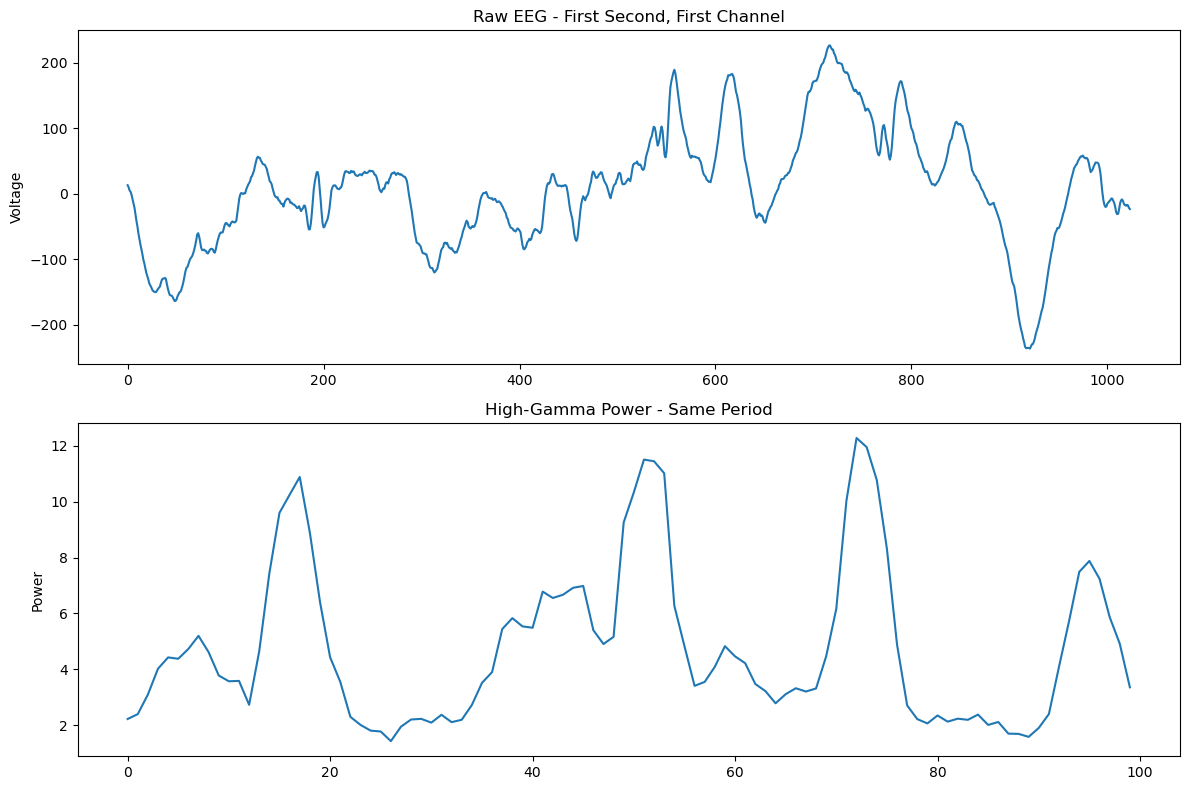

In [18]:
# Extract features
features = extractHG(eeg, 1024, windowLength=0.05, frameshift=0.01)
print("\n2. AFTER FEATURE EXTRACTION:")
print(f"   Features shape: {features.shape}")
print(f"   Each row = 50ms window, Each column = channel's high-gamma power")

# Downsample labels
labels = downsampleLabels(stimuli, 1024, windowLength=0.05, frameshift=0.01)
print("\n3. AFTER LABEL DOWNSAMPLING:")
print(f"   Labels shape: {labels.shape}")
print(f"   Unique labels: {np.unique(labels)[:5]}")
# Visualize
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Raw EEG (1 second, 1 channel)
axes[0].plot(eeg[:1024, 0])
axes[0].set_title('Raw EEG - First Second, First Channel')
axes[0].set_ylabel('Voltage')

# Features for same period (100 windows = 1 second)
axes[1].plot(features[:100, 0])
axes[1].set_title('High-Gamma Power - Same Period')
axes[1].set_ylabel('Power')

plt.tight_layout()
plt.show()

1. Raw EEG: (10000, 127)
2. After high-gamma: (200, 127)
3. With temporal context: (200, 1143)
4. After PCA: (200, 100)


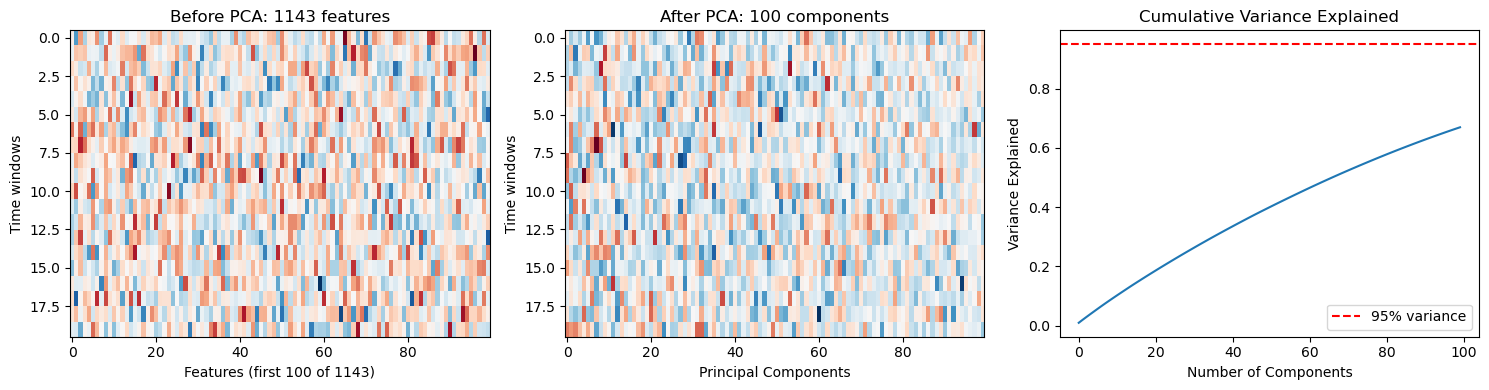


Key insight: PCA reduces 1143 features to 100 components
These 50 components capture ~67.0% of the variance


In [19]:
# Simulate your data flow
n_samples = 10000
n_channels = 127

# 1. Raw EEG: many channels over time
raw_eeg = np.random.randn(n_samples, n_channels)
print(f"1. Raw EEG: {raw_eeg.shape}")

# 2. High-gamma features: windows × channels
n_windows = 200  # After windowing
features = np.random.randn(n_windows, n_channels)
print(f"2. After high-gamma: {features.shape}")

# 3. With temporal context: windows × (channels × context)
temporal_context = 9
features_stacked = np.random.randn(n_windows, n_channels * temporal_context)
print(f"3. With temporal context: {features_stacked.shape}")

# 4. After PCA: windows × components
pca = PCA(n_components=100)
features_pca = pca.fit_transform(features_stacked)
print(f"4. After PCA: {features_pca.shape}")

# Visualize what PCA does
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Before PCA: 1143 dimensions
axes[0].imshow(features_stacked[:20, :100], aspect='auto', cmap='RdBu')
axes[0].set_title(f'Before PCA: {features_stacked.shape[1]} features')
axes[0].set_xlabel('Features (first 100 of 1143)')
axes[0].set_ylabel('Time windows')

# After PCA: 50 dimensions
axes[1].imshow(features_pca[:20, :], aspect='auto', cmap='RdBu')
axes[1].set_title(f'After PCA: {features_pca.shape[1]} components')
axes[1].set_xlabel('Principal Components')
axes[1].set_ylabel('Time windows')

# Explained variance
explained_var = pca.explained_variance_ratio_[:100]
axes[2].plot(np.cumsum(explained_var))
axes[2].set_title('Cumulative Variance Explained')
axes[2].set_xlabel('Number of Components')
axes[2].set_ylabel('Variance Explained')
axes[2].axhline(0.95, color='r', linestyle='--', label='95% variance')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nKey insight: PCA reduces {features_stacked.shape[1]} features to {features_pca.shape[1]} components")
print(f"These 50 components capture ~{np.sum(explained_var):.1%} of the variance")